In [1]:
import numpy as np
from gaussrnd import *
import matplotlib.pyplot as plt
from forwardmodel import *
from helper import *

# -----------------------------------------
# Configuration
# -----------------------------------------
iteration_data = -6

# Level-set wave speed bounds
c_high = np.exp(0.27)
c_low  = np.exp(-0.27)

# Solver settings
N = 100
dt = 2e-4
L = 1
f0 = 20
dx = L / N
xs_frac = 0.5
T = 1
Np1 = N + 1
i = np.arange(1, N + 1)
x_center = (i - 0.5) / N
i = np.arange(0, Np1)
x_nodes = i * dx
Lmat = build_L_neumann_matrix(Np1, dx)

# Receiver setup
Nr = 10
Nrp2 = Nr + 2
i = np.arange(0, Nrp2)
dx_obs = L / (Nr + 1)
ratio_obs_to_discritization = int(dx_obs / dx)
x_nodes_rec = i * dx_obs
recv_idx = (i * ratio_obs_to_discritization)[1:-1]
x_recv = x_nodes[recv_idx]

dt_obs = dt
time_idx = np.arange(0, int(T / dt_obs)) * int(dt_obs / dt)
t_recv = time_idx * dt

# -----------------------------------------
# Load true field and run forward model
# -----------------------------------------
file_true = "./../../../Data/Experiment7/wave_iteration" + str(iteration_data) + ".npz"
true_data = np.load(file_true)
u_true = true_data["u_true"].reshape(N)

U_true_nodes = np.interp(x_nodes, x_center, u_true)
c_true = levelset_to_c_binary(U_true_nodes, c_high=c_high, c_low=c_low)

x, t, P = solve_wave_1d(c=c_true, Lmat=Lmat, L=L, T=T, f0=f0, xs_frac=xs_frac, dt=dt)
print("Forward model solved. P shape:", P.shape)


Forward model solved. P shape: (5000, 101)


In [2]:
# sigma_obs = 5e-3
# ArrivalTimes_noisy = ArrivalTimes + sigma_obs * np.random.randn(len(ArrivalTimes))

In [3]:
# import matplotlib.pyplot as plt
# import matplotlib as mpl

# mpl.rcParams.update({
#     "font.family": "serif",
#     "font.size": 8,
#     "axes.labelsize": 8,
#     "xtick.labelsize": 7,
#     "ytick.labelsize": 7,
#     "legend.fontsize": 7,
# })

In [4]:
# import matplotlib as mpl
# from matplotlib.gridspec import GridSpec

# mpl.rcParams.update({
#     "font.family": "serif",
#     "font.serif": ["Times New Roman"],
#     "font.size": 8,
#     "axes.labelsize": 8,
#     "xtick.labelsize": 7,
#     "ytick.labelsize": 7,
# })

# fig = plt.figure(figsize=(3.7, 2.5))
# gs = GridSpec(1, 2, width_ratios=[20, 1])

# ax1 = fig.add_subplot(gs[0, 0])
# cax = fig.add_subplot(gs[0, 1])

# im = ax1.imshow(
#     P,
#     extent=[x_nodes[0], x_nodes[-1], t[-1], t[0]],
#     aspect='auto',
#     cmap='viridis',
# )

# for xr in x_recv:
#     ax1.axvline(x=xr, color='red', linestyle='--', linewidth=0.8)

# ax1.set_xlabel("Location")
# ax1.set_ylabel("Time")
# fig.colorbar(im, cax=cax)

# plt.tight_layout(pad=0.3)
# plt.savefig("../../../Figs/Experiment7/wavefield_iteration" + str(iteration_data) + ".png",
#             dpi=300, bbox_inches='tight', pad_inches=0.01)
# plt.show()


In [5]:
# 

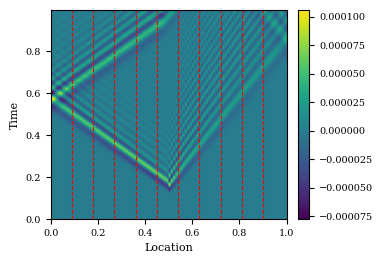

In [7]:
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

mpl.rcParams.update({
    "font.family": "serif",
    "font.size": 8,
    "axes.labelsize": 8,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
})

fig = plt.figure(figsize=(3.7, 2.5))
gs = GridSpec(1, 2, width_ratios=[20, 1])

ax1 = fig.add_subplot(gs[0, 0])
cax = fig.add_subplot(gs[0, 1])

im = ax1.imshow(
    P[::-1, :],  # flip the wavefield vertically
    extent=[x_nodes[0], x_nodes[-1], t[0], t[-1]],
    origin="upper",
    aspect="auto",
    cmap="viridis",
)

for xr in x_recv:
    ax1.axvline(x=xr, color="red", linestyle="--", linewidth=0.8)

ax1.set_xlabel("Location")
ax1.set_ylabel("Time")

fig.colorbar(im, cax=cax)

plt.tight_layout(pad=0.3)

plt.savefig(
    "../../../Figs/Experiment7/wavefield_iteration" + str(iteration_data) + ".png",
    dpi=300,
    bbox_inches="tight",
    pad_inches=0.01,
)

plt.show()